In [1]:
from pathlib import Path
import pandas as pd

metadata_path_root = Path("../tmp/metadata")
linked_metadata_df = pd.read_csv(metadata_path_root / "linked_metadata.csv")

linked_metadata_df.head()

,Unnamed: 0,Unnamed: 0_x,UUID,Original\nFilename,Site_x,Day_x,Plant #,Level_x,Index_x,View,...,Index_y,Healthy,Leaf Miner?,Rust?,"Other Insect? (catipillar bites, etc.)","Mechanical? (human, animal, herbicide, etc.)",Other? (Please mark),Date Labeled,Time Start,Time End
0,0,1,NaN,IMG_0341.png,1.0,16.0,NaN,NaN,1.0,D,...,1,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN
1,1,3,NaN,IMG_0342.png,1.0,16.0,NaN,NaN,1.0,V,...,1,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN
2,2,5,NaN,IMG_0355.png,1.0,16.0,NaN,NaN,2.0,D,...,2,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN
3,3,7,NaN,IMG_0356.png,1.0,16.0,NaN,NaN,2.0,V,...,2,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN
4,4,9,NaN,IMG_0351.png,1.0,16.0,NaN,NaN,3.0,D,...,3,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Set Global matplotlib styles
import matplotlib.pyplot as plt

plt.style.use("ggplot")

Index(['D', 'V'], dtype='object', name='View')

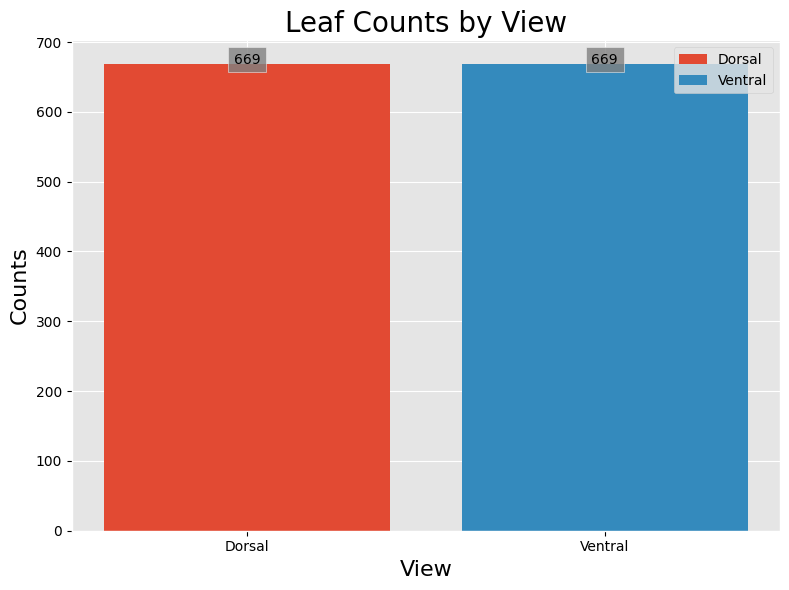

In [ ]:
view_counts = linked_metadata_df.View.value_counts()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
view_name_map = dict(D="Dorsal", V="Ventral")
for i, (view, cnt) in enumerate(view_counts.items()):
    view_name_mapped = view_name_map[view]
    ax.bar(view_name_mapped, cnt, label=view_name_mapped)
    ax.text(i, cnt, cnt, ha="center", bbox=dict(facecolor="grey", alpha=0.8))
ax.set_title("Leaf Counts by View", fontdict=dict(size=20))
ax.set_xlabel("View", fontdict=dict(color="black", size=16))
ax.set_ylabel("Counts", fontdict=dict(color="black", size=16))
ax.tick_params(colors="black", which="both")
ax.legend()
fig.tight_layout()
fig.show()

Number of rows: 1338


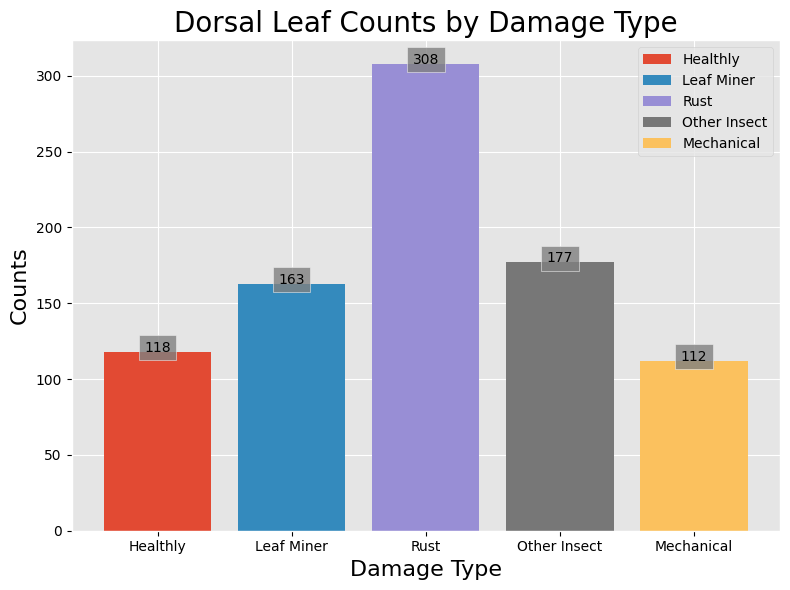

In [ ]:
print(f"Number of rows: {linked_metadata_df.shape[0]}")

dmg_cnts = {}
label_replacements = ["Healthly", "Leaf Miner", "Rust", "Other Insect", "Mechanical"]
for i, dmg_lbl in enumerate(
    [
        "Healthy",
        "Leaf Miner?",
        "Rust?",
        "Other Insect? (catipillar bites, etc.)",
        "Mechanical? (human, animal, herbicide, etc.)",
    ]
):
    dmg_cnts[label_replacements[i]] = int(
        (
            (linked_metadata_df[dmg_lbl] == "Yes") & (linked_metadata_df.View == "D")
        ).sum()
    )

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for i, lbl in enumerate(label_replacements):
    cnt = dmg_cnts[lbl]
    ax.bar(lbl, cnt, label=lbl)
    ax.text(i, cnt, cnt, ha="center", bbox=dict(facecolor="grey", alpha=0.8))
ax.set_title("Dorsal Leaf Counts by Damage Type", fontdict=dict(size=20))
ax.set_xlabel("Damage Type", fontdict=dict(color="black", size=16))
ax.set_ylabel("Counts", fontdict=dict(color="black", size=16))
ax.tick_params(colors="black", which="both")
ax.legend()
fig.tight_layout()
fig.show()


['Healthy', 'Leaf Miner', 'Rust', 'Other Insect', 'Mechanical']


/home/carlyn.1/tmp/ipykernel_3097573/1165120700.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels)
/home/carlyn.1/tmp/ipykernel_3097573/1165120700.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels)


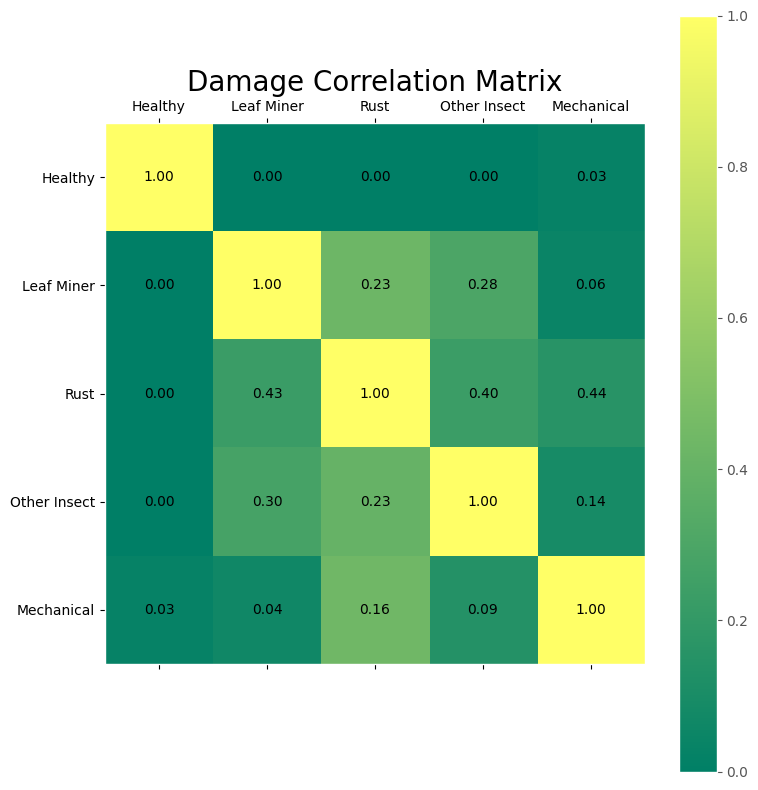

In [ ]:
from collections import defaultdict
from matplotlib.cm import ScalarMappable

just_dorsal_labels_df = linked_metadata_df[linked_metadata_df.View == "D"][
    [
        "Healthy",
        "Leaf Miner?",
        "Rust?",
        "Other Insect? (catipillar bites, etc.)",
        "Mechanical? (human, animal, herbicide, etc.)",
    ]
]
just_dorsal_labels_df = just_dorsal_labels_df.rename(
    columns={
        "Leaf Miner?": "Leaf Miner",
        "Rust?": "Rust",
        "Other Insect? (catipillar bites, etc.)": "Other Insect",
        "Mechanical? (human, animal, herbicide, etc.)": "Mechanical",
    }
)
yes_index = just_dorsal_labels_df == "Yes"
just_dorsal_labels_df[yes_index] = 1
just_dorsal_labels_df[~yes_index] = 0

labels = ["Healthy", "Leaf Miner", "Rust", "Other Insect", "Mechanical"]
lbl_idx = {lbl: just_dorsal_labels_df[lbl] == 1 for lbl in labels}

correlation_values = []
for rlbl in labels:
    row = []
    base_lbl_cnt = lbl_idx[rlbl].sum()
    for clbl in labels:
        corr_cnt = (lbl_idx[rlbl] & lbl_idx[clbl]).sum()
        row.append(corr_cnt / base_lbl_cnt)
    correlation_values.append(row)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title("Damage Correlation Matrix", fontdict=dict(size=20))

cax = ax.matshow(correlation_values, interpolation="nearest", cmap="summer")
ax.set_xticklabels([""] + labels)
ax.set_yticklabels([""] + labels)
ax.grid(False)

for r, rlbl in enumerate(labels):
    for c, clbl in enumerate(labels):
        value = f"{correlation_values[r][c]:.2f}"
        ax.text(r, c, value, va="center", ha="center")

ax.tick_params(colors="black", which="both")
fig.colorbar(cax)
fig.tight_layout()
fig.show()

print(labels)

In [ ]:
corr = just_dorsal_labels_df.corr()
corr.style.background_gradient(cmap="coolwarm")

,Healthy,Leaf Miner,Rust,Other Insect,Mechanical
Healthy,1.000000,-0.262654,-0.427452,-0.277568,-0.176000
Leaf Miner,-0.262654,1.000000,-0.035233,0.046372,-0.189221
Rust,-0.427452,-0.035233,1.000000,-0.071310,-0.020592
Other Insect,-0.277568,0.046372,-0.071310,1.000000,-0.123734
Mechanical,-0.176000,-0.189221,-0.020592,-0.123734,1.000000


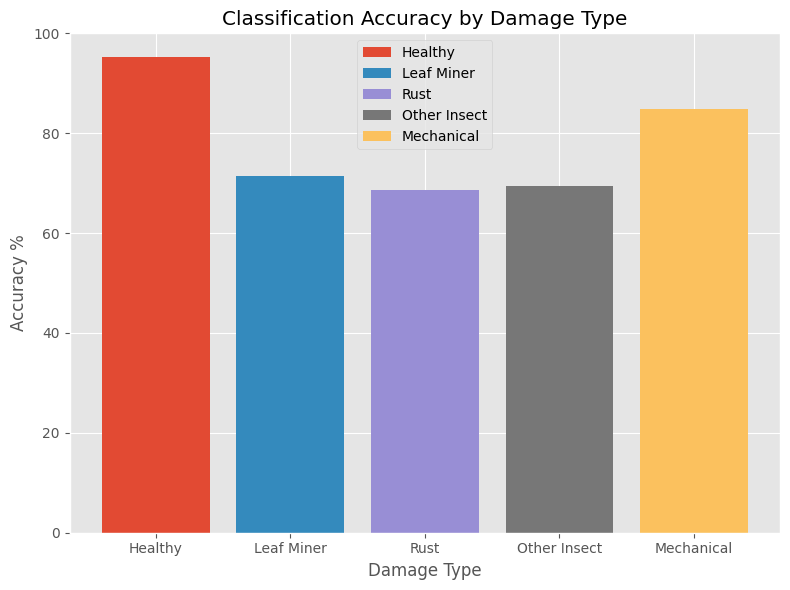

In [ ]:
"""
from train-classifier.ipynb
Healthy: 95.24%
- Leaf Miner: 71.4%
- Rust: 68.6%
- Other Insect: 69.5%
- Mechanical Damage: 84.8%
"""

classification_accuracies = {
    "Healthy": 95.24,
    "Leaf Miner": 71.40,
    "Rust": 68.6,
    "Other Insect": 69.5,
    "Mechanical": 84.8,
}
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for lbl, acc in classification_accuracies.items():
    ax.bar(lbl, acc, label=lbl)
    ax.text(i, acc, f"{acc}%", ha="center", bbox=dict(facecolor="grey", alpha=0.8))

ax.tick_params(colors="black", which="both")
ax.set_title("Classification Accuracy by Damage Type", fontdict=dict(size=20))
ax.set_xlabel("Damage Type", fontdict=dict(color="black", size=16))
ax.set_ylabel("Accuracy %", fontdict=dict(color="black", size=16))
ax.legend()
fig.tight_layout()
fig.show()
